## **1. IMPORT LIBRARIES**

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, pickle
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)

## **2. MEMUAT DATA DAN INTEGRASI (*TWO-STAGE MODELING*)**

In [26]:
PELANGGAN = '../dataset/data_pelanggan.csv' 
df_pelanggan = pd.read_csv(PELANGGAN)
print(f'Data pelanggan: {df_pelanggan.shape[0]:,} baris')
display(df_pelanggan.head(3))

nlp_path = '../output/severity_per_user.csv'
if not os.path.exists(nlp_path):
    nlp_path = '../dummy/severity_per_user.csv'  
df_nlp = pd.read_csv(nlp_path)
df_nlp.rename(columns={'predicted_severity': 'keluhan'}, inplace=True)
df_nlp['keluhan'] = df_nlp['keluhan'].astype(int)
print(f'\nData keluhan (output NLP): {df_nlp.shape[0]:,} user')
display(df_nlp.head(3))

df_merge = df_pelanggan.merge(df_nlp, on='kode_user', how='left')
df_merge['keluhan'] = df_merge['keluhan'].fillna(1).astype(int)

print(f'\nHasil Integrasi Data (sesuai jurnal):')
print(f'Total pelanggan: {df_merge.shape[0]:,}')
display(df_merge[['kode_user', 'paket_satuan', 'lama_aktivasi', 'keluhan', 'status_log']].head(10))

print(f'\nDistribusi keluhan:')
display(df_merge['keluhan'].value_counts().sort_index().to_frame('Jumlah'))


Data pelanggan: 7,382 baris


,id,kode_user,paket_satuan,status_log,lama_aktivasi
0,1,GI0046,10 Mbps,n,55 bulan
1,2,GJ0033,5 Mbps,n,55 bulan
2,3,GJ0032,10 Mbps,y,55 bulan



Data keluhan (output NLP): 7,370 user


,kode_user,keluhan
0,AT0003,1
1,AT0011,2
2,AT0013,1



Hasil Integrasi Data (sesuai jurnal):
Total pelanggan: 7,382


,kode_user,paket_satuan,lama_aktivasi,keluhan,status_log
0,GI0046,10 Mbps,55 bulan,4,n
1,GJ0033,5 Mbps,55 bulan,4,n
2,GJ0032,10 Mbps,55 bulan,2,y
3,GJ0029,5 Mbps,55 bulan,2,y
4,GJ0024,10 Mbps,55 bulan,2,y
5,GJ0019,5 Mbps,55 bulan,3,y
6,GJ0004,15 Mbps,55 bulan,1,y
7,GI0035,10 Mbps,55 bulan,2,y
8,KJ2734,5 Mbps,55 bulan,2,y
9,KP2866,10 Mbps,55 bulan,1,y



Distribusi keluhan:


,Jumlah
keluhan,
1,1109
2,5283
3,536
4,454


## **3. FEATURE ENGINEERING DAN PRA-PEMROSESAN (LABEL CHURN)**

In [27]:
df_model = df_merge.copy()

df_model['lama_aktivasi_bulan'] = df_model['lama_aktivasi'].astype(str).str.extract(r'(\d+)').astype(float)
df_model['lama_aktivasi_bulan'] = df_model['lama_aktivasi_bulan'].fillna(df_model['lama_aktivasi_bulan'].median())
df_model['paket_mbps'] = df_model['paket_satuan'].astype(str).str.extract(r'(\d+)').astype(float)
df_model['paket_mbps'] = df_model['paket_mbps'].fillna(df_model['paket_mbps'].median())

df_model['churn'] = np.where(df_model['status_log'].astype(str).str.lower().eq('y'), 0, 1)


feature_cols = ['paket_mbps', 'lama_aktivasi_bulan', 'keluhan']
X = df_model[feature_cols]
y = df_model['churn']

print('Distribusi Label Churn:')
display(y.value_counts().to_frame('Jumlah'))
print()
print('Fitur yang digunakan:', feature_cols)
display(X.describe().round(2))


Distribusi Label Churn:


,Jumlah
churn,
1,3691
0,3691



Fitur yang digunakan: ['paket_mbps', 'lama_aktivasi_bulan', 'keluhan']


,paket_mbps,lama_aktivasi_bulan,keluhan
count,7382.00,7382.00,7382.00
mean,9.26,21.89,2.05
std,11.91,16.70,0.68
min,5.00,0.00,1.00
25%,5.00,9.00,2.00
50%,5.00,17.00,2.00
75%,10.00,33.00,2.00
max,100.00,55.00,4.00


## **4. EKSPLORASI DATA (VISUALISASI EDA)**

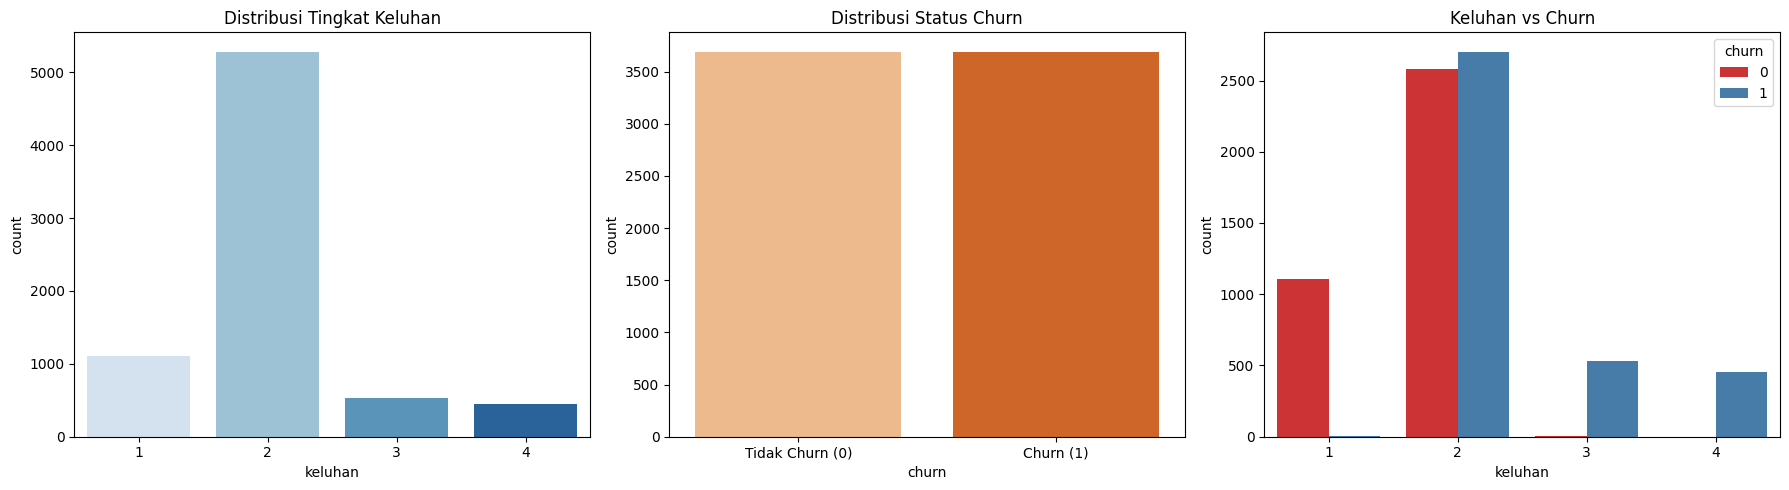

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df_model, x='keluhan', palette='Blues', ax=axes[0])
axes[0].set_title('Distribusi Tingkat Keluhan')

sns.countplot(data=df_model, x='churn', palette='Oranges', ax=axes[1])
axes[1].set_title('Distribusi Status Churn')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Tidak Churn (0)', 'Churn (1)'])

sns.countplot(data=df_model, x='keluhan', hue='churn', palette='Set1', ax=axes[2])
axes[2].set_title('Keluhan vs Churn')
plt.tight_layout(); plt.show()


## **5. MODELING: PERANCANGAN ALGORITMA DECISION TREE**

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Training: {X_train.shape[0]:,} | Testing: {X_test.shape[0]:,}')

clf_dt = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)
clf_dt.fit(X_train, y_train)
y_pred_dt = clf_dt.predict(X_test)
print('Decision Tree berhasil di-training.')


Training: 5,905 | Testing: 1,477
Decision Tree berhasil di-training.


## **6. EVALUASI DAN AKURASI (ROC-AUC)**

===== DECISION TREE =====


,Accuracy,Precision,Recall,F1-Score
0,0.8429,0.7921,0.9295,0.8554


              precision    recall  f1-score   support

           0       0.91      0.76      0.83       739
           1       0.79      0.93      0.86       738

    accuracy                           0.84      1477
   macro avg       0.85      0.84      0.84      1477
weighted avg       0.85      0.84      0.84      1477



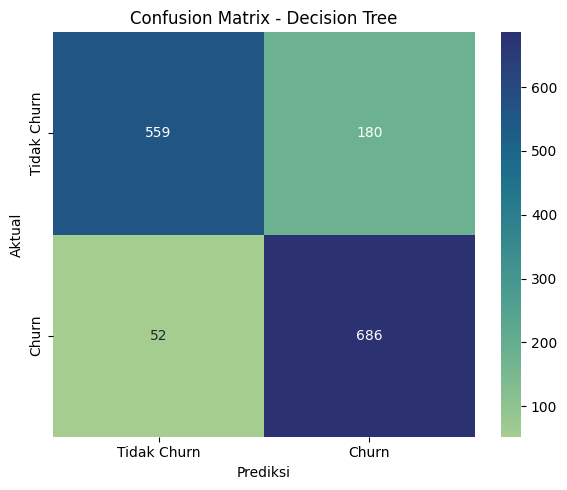

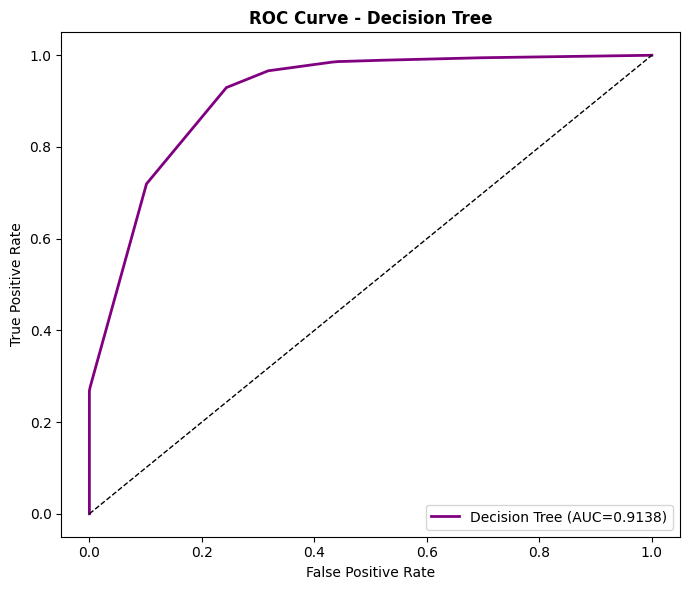

In [30]:
print('===== DECISION TREE =====')
display(pd.DataFrame([{
    'Accuracy': f'{accuracy_score(y_test, y_pred_dt):.4f}',
    'Precision': f'{precision_score(y_test, y_pred_dt, zero_division=0):.4f}',
    'Recall': f'{recall_score(y_test, y_pred_dt, zero_division=0):.4f}',
    'F1-Score': f'{f1_score(y_test, y_pred_dt, zero_division=0):.4f}',
}]))
print(classification_report(y_test, y_pred_dt, zero_division=0))

cm = confusion_matrix(y_test, y_pred_dt)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='crest',
            xticklabels=['Tidak Churn', 'Churn'],
            yticklabels=['Tidak Churn', 'Churn'], ax=ax)
ax.set_title('Confusion Matrix - Decision Tree')
ax.set_xlabel('Prediksi'); ax.set_ylabel('Aktual')
plt.tight_layout(); plt.show()

y_score = clf_dt.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_score)
auc = roc_auc_score(y_test, y_score)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, label=f'Decision Tree (AUC={auc:.4f})', color='purple', lw=2)
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve - Decision Tree', fontweight='bold')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()

## **7. INTERPRETASI POIN POHON KEPUTUSAN DAN IMPORTANCE**

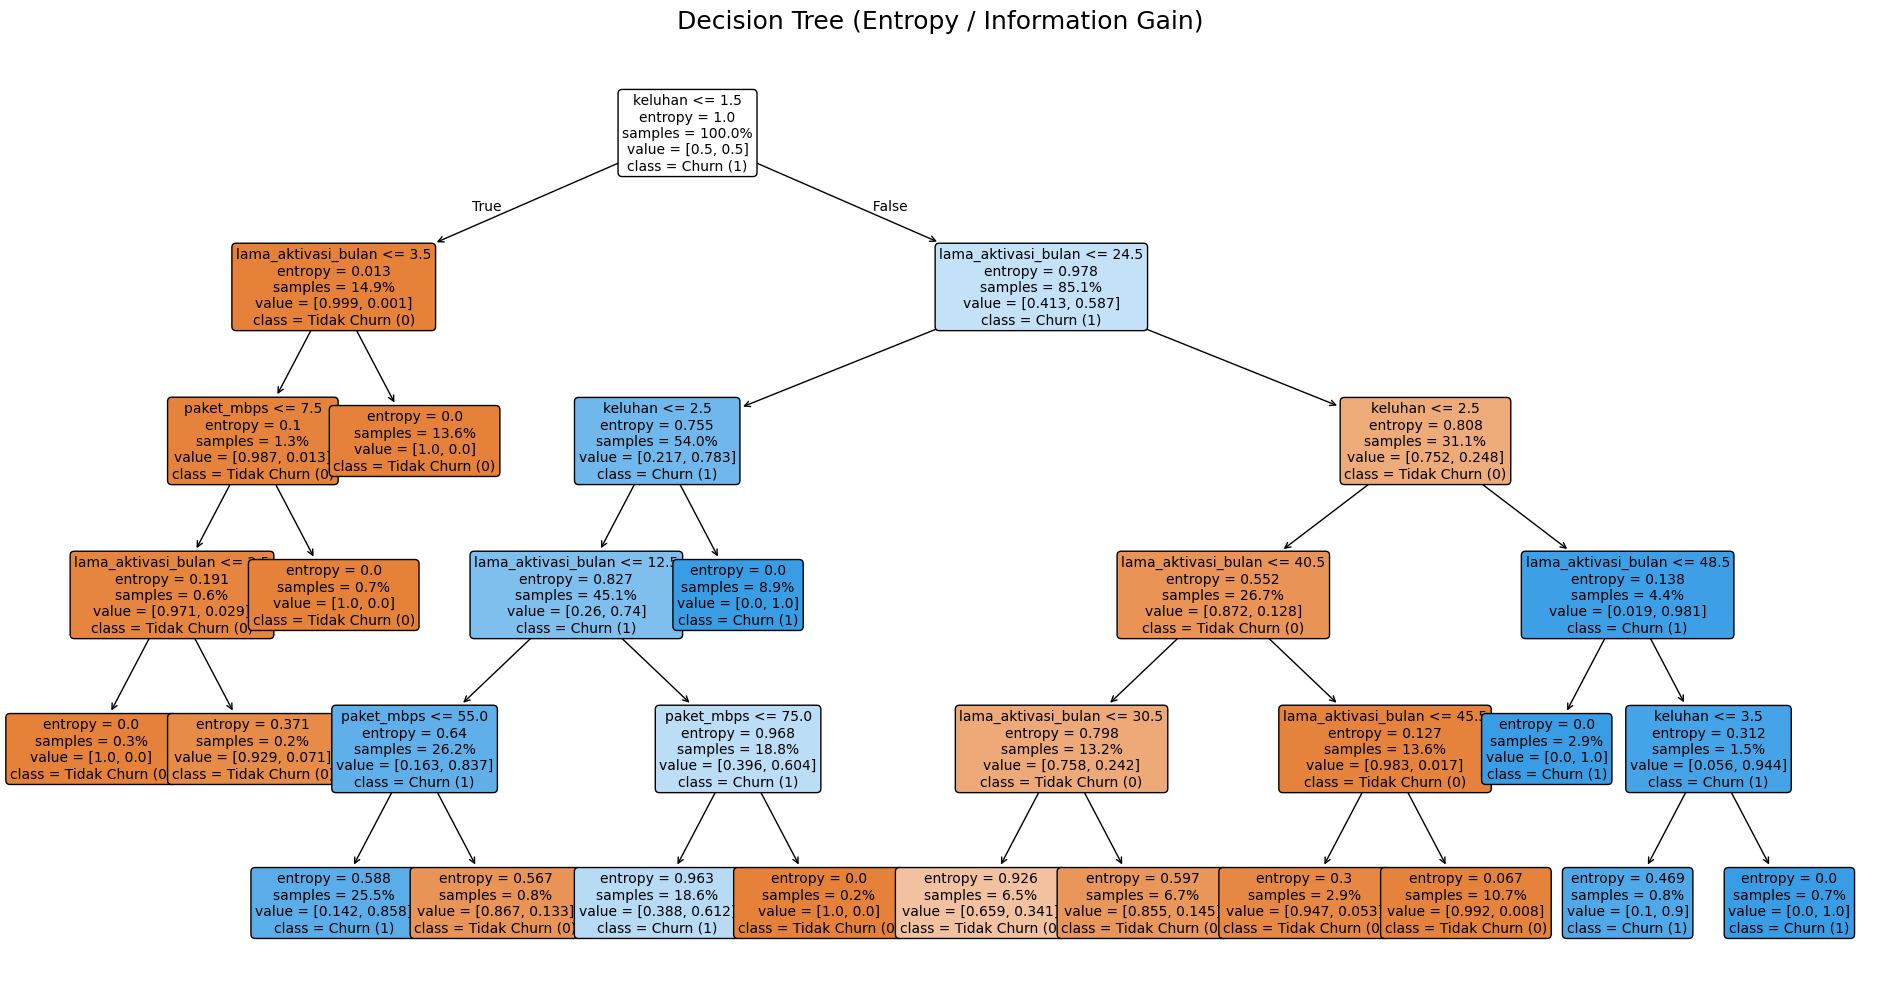

,Fitur,Importance
2,keluhan,0.548510
1,lama_aktivasi_bulan,0.419847
0,paket_mbps,0.031642


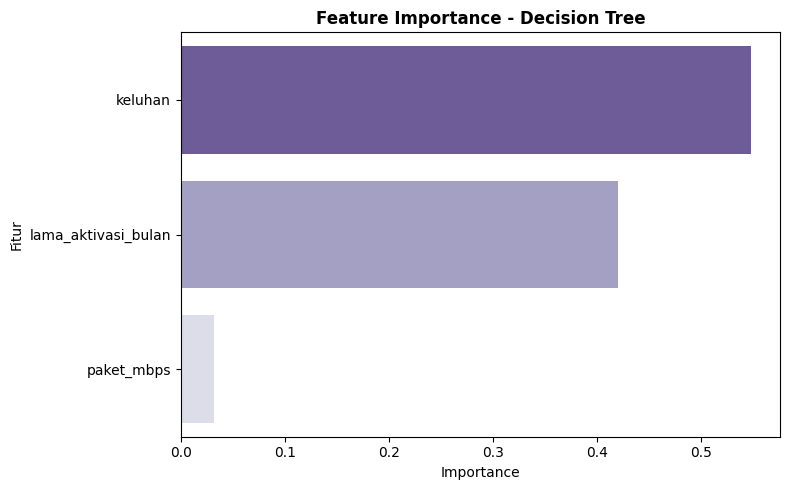

In [31]:
plt.figure(figsize=(24, 12))
plot_tree(
    clf_dt,
    feature_names=feature_cols,
    class_names=['Tidak Churn (0)', 'Churn (1)'],
    filled=True, rounded=True, fontsize=10, proportion=True
)
plt.title('Decision Tree (Entropy / Information Gain)', fontsize=18, pad=20)
plt.show()

feat_imp = pd.DataFrame({
    'Fitur': feature_cols,
    'Importance': clf_dt.feature_importances_
}).sort_values('Importance', ascending=False)
display(feat_imp)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=feat_imp, x='Importance', y='Fitur', palette='Purples_r', ax=ax)
ax.set_title('Feature Importance - Decision Tree', fontweight='bold')
plt.tight_layout(); plt.show()

## **8. EKSPOR HASIL PREDIKSI KESELURUHAN (OUTPUT)**

In [32]:
df_model['pred_churn_dt'] = clf_dt.predict(X)

os.makedirs('../output', exist_ok=True)
df_model.to_csv('../output/data_churn_prediction.csv', index=False)
print('CSV tersimpan: output/data_churn_prediction.csv')

os.makedirs('../model', exist_ok=True)
with open('../model/decision_tree_churn.pkl', 'wb') as f:
    pickle.dump(clf_dt, f)
print('PKL tersimpan: model/decision_tree_churn.pkl')

display(df_model[['kode_user', 'paket_mbps', 'lama_aktivasi_bulan', 'keluhan',
                   'churn', 'pred_churn_dt']].head(10))

print()
print('Distribusi prediksi:')
display(pd.DataFrame({
    'Model': ['Decision Tree'],
    'Prediksi Churn': [(df_model['pred_churn_dt']==1).sum()],
    'Prediksi Tidak Churn': [(df_model['pred_churn_dt']==0).sum()]
}))

CSV tersimpan: output/data_churn_prediction.csv
PKL tersimpan: model/decision_tree_churn.pkl


,kode_user,paket_mbps,lama_aktivasi_bulan,keluhan,churn,pred_churn_dt
0,GI0046,10.0,55.0,4,1,1
1,GJ0033,5.0,55.0,4,1,1
2,GJ0032,10.0,55.0,2,0,0
3,GJ0029,5.0,55.0,2,0,0
4,GJ0024,10.0,55.0,2,0,0
5,GJ0019,5.0,55.0,3,0,1
6,GJ0004,15.0,55.0,1,0,0
7,GI0035,10.0,55.0,2,0,0
8,KJ2734,5.0,55.0,2,0,0
9,KP2866,10.0,55.0,1,0,0



Distribusi prediksi:


,Model,Prediksi Churn,Prediksi Tidak Churn
0,Decision Tree,4254,3128
